In [27]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  r2_score, mean_squared_error

import joblib

# Loading the data

In [3]:
path = "../Data/Calories_burned_data.csv"
df = pd.read_csv(path)
print(df.head())
print(df.info())

   Gender  Age  Height(cm)  Weight(kg)   BMI  Running Time(min)  \
0    Male   49         184          74  20.4                 78   
1  Female   56         182          70  23.2                 98   
2    Male   49         170          85  27.4                 91   
3    Male   21         181          59  24.0                 89   
4    Male   47         172          86  29.8                 79   

   Running Speed(km/h)  Distance(km)  Average Heart Rate  Calories Burned  
0                  9.5          3.00                 139              973  
1                 10.2          5.23                 165              494  
2                 10.4          7.61                 134              954  
3                 13.4         14.19                 144              570  
4                  9.8          3.84                 149              385  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null C

In [ ]:
# df = df.drop("User_ID", axis=1)

Checking for objects and converting them to binary

In [5]:
df["Gender"].dtype == object
df.head()

,Gender,Age,Height(cm),Weight(kg),BMI,Running Time(min),Running Speed(km/h),Distance(km),Average Heart Rate,Calories Burned
0,Male,49,184,74,20.4,78,9.5,3.00,139,973
1,Female,56,182,70,23.2,98,10.2,5.23,165,494
2,Male,49,170,85,27.4,91,10.4,7.61,134,954
3,Male,21,181,59,24.0,89,13.4,14.19,144,570
4,Male,47,172,86,29.8,79,9.8,3.84,149,385


In [6]:
df["Gender"] = df["Gender"].map({'Male': 0, 'Female': 1})

In [7]:
df.head()

,Gender,Age,Height(cm),Weight(kg),BMI,Running Time(min),Running Speed(km/h),Distance(km),Average Heart Rate,Calories Burned
0,0,49,184,74,20.4,78,9.5,3.00,139,973
1,1,56,182,70,23.2,98,10.2,5.23,165,494
2,0,49,170,85,27.4,91,10.4,7.61,134,954
3,0,21,181,59,24.0,89,13.4,14.19,144,570
4,0,47,172,86,29.8,79,9.8,3.84,149,385


In [10]:
df.isnull().sum()
df["Gender"].value_counts()

Gender
0    100
1    100
Name: count, dtype: int64

# Feature Engineering 

In [11]:
df["pace(min_per_km)"] = df["Running Time(min)"]/df["Distance(km)"]

Handling Outliers

<Axes: >

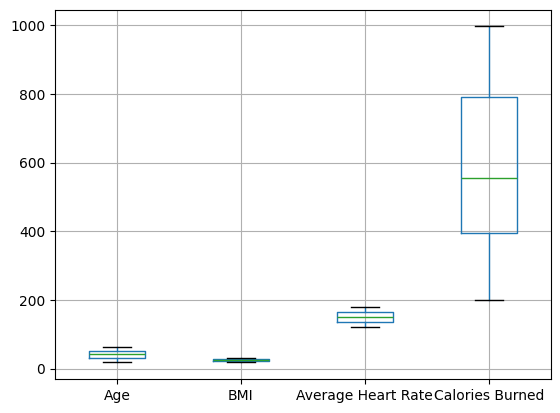

In [14]:
df[['Age','BMI','Average Heart Rate', 'Calories Burned']].boxplot()

# Splitting the data 

In [15]:
X = df.drop("Calories Burned",axis=1)
y = df["Calories Burned"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)

(160, 10)
(40, 10)


In [ ]:
# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [25]:
pred = model.predict(X_test)

In [26]:
print(r2_score(y_test, pred))
print(mean_squared_error(y_test, pred,squared=False))

9.083284675781567e-05
205.15560948947996


d:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Save & Load the Model and Scaled Features

In [28]:
joblib.dump(model, "../Model/calorie_model.pkl")
joblib.dump(scaler, "../Model/scaler.pkl")

['../Model/scaler.pkl']